In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from scipy.spatial import ConvexHull
from sklearn.cluster import KMeans

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
# Load the dataset
df = pd.read_csv("/Users/priya/Downloads/Elepant_dataset.csv")
# Display the first few rows
df.head()


,event-id,visible,timestamp,location-long,location-lat,manually-marked-outlier,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name
0,37697833220,True,2008-10-29 00:00:38.000,16.231159,-19.067336,NaN,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
1,37697833872,True,2008-10-29 00:00:48.000,16.231540,-19.066834,NaN,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
2,37697833849,True,2008-10-29 00:00:58.000,16.231527,-19.066817,NaN,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
3,37697833841,True,2008-10-29 00:01:08.000,16.231521,-19.066811,NaN,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
4,37697833837,True,2008-10-29 00:01:18.000,16.231520,-19.066811,NaN,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...


In [27]:
# Inspect shape and structural information
df.shape

(2930263, 19)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930263 entries, 0 to 2930262
Data columns (total 19 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   event-id                         int64         
 1   visible                          bool          
 2   timestamp                        datetime64[us]
 3   location-long                    float64       
 4   location-lat                     float64       
 5   manually-marked-outlier          float64       
 6   sensor-type                      str           
 7   individual-taxon-canonical-name  str           
 8   tag-local-identifier             str           
 9   individual-local-identifier      str           
 10  study-name                       str           
 11  year                             int32         
 12  month                            int32         
 13  day                              int32         
 14  hour                             int32       

In [26]:
# Display missing value counts
print("\nMissing Values Per Column:")
print(df.isnull().sum())


Missing Values Per Column:
event-id                                 0
visible                                  0
timestamp                                0
location-long                            0
location-lat                             0
manually-marked-outlier            2930263
sensor-type                              0
individual-taxon-canonical-name          0
tag-local-identifier                     0
individual-local-identifier              0
study-name                               0
year                                     0
month                                    0
day                                      0
hour                                     0
weekday                                  0
prev_lat                                15
prev_long                               15
distance_km                              0
dtype: int64


In [10]:
# columns that are actually available in the DataFrame
print("Available columns:")
print(df.columns.tolist())

Available columns:
['event-id', 'visible', 'timestamp', 'location-long', 'location-lat', 'manually-marked-outlier', 'sensor-type', 'individual-taxon-canonical-name', 'tag-local-identifier', 'individual-local-identifier', 'study-name']


In [11]:
# Convert timestamp to standard datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract all required temporal attributes efficiently
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()

print("Temporal feature engineering complete.")
df[['timestamp', 'year', 'month', 'day', 'hour', 'weekday']].head()

Temporal feature engineering complete.


,timestamp,year,month,day,hour,weekday
0,2008-10-29 00:00:38,2008,10,29,0,Wednesday
1,2008-10-29 00:00:48,2008,10,29,0,Wednesday
2,2008-10-29 00:00:58,2008,10,29,0,Wednesday
3,2008-10-29 00:01:08,2008,10,29,0,Wednesday
4,2008-10-29 00:01:18,2008,10,29,0,Wednesday


Tracking Counts Per Elephant:
individual-local-identifier
LA26    452758
LA14    414851
LA11    396557
LA12    257295
LA13    243475
LA3     184046
LA7     180224
LA8     176026
LA2     172930
LA6     117432
LA1      98760
LA4      80758
LA27     69476
LA5      68343
LA15     17332
Name: count, dtype: int64


/var/folders/m2/9pslhn3s0yd_20r766r531gh0000gn/T/ipykernel_3270/2551471835.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=elephant_counts.index, y=elephant_counts.values, palette='viridis')


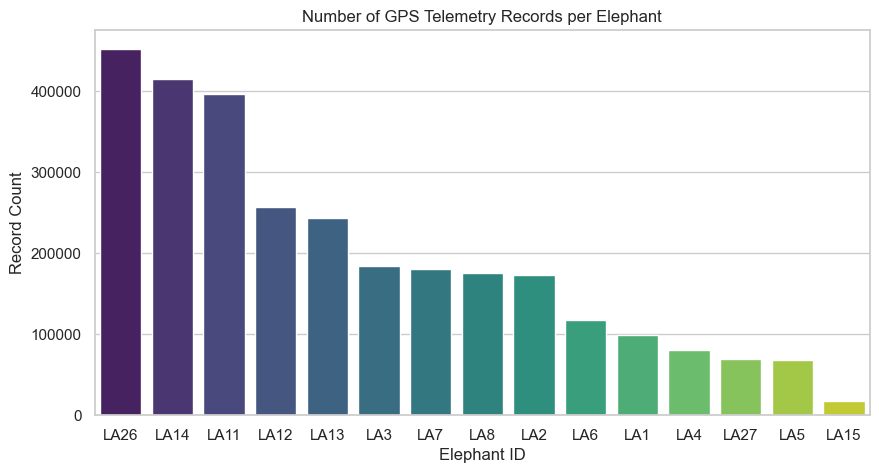

In [13]:
# 1. Individual Elephant Counts
elephant_counts = df['individual-local-identifier'].value_counts()
print("Tracking Counts Per Elephant:")
print(elephant_counts)

# Plot Elephant Tracking Counts
plt.figure(figsize=(10, 5))
sns.barplot(x=elephant_counts.index, y=elephant_counts.values, palette='viridis')
plt.title('Number of GPS Telemetry Records per Elephant')
plt.xlabel('Elephant ID')
plt.ylabel('Record Count')
plt.show()

# 2. Seasonal / Monthly Activity Distribution
month_counts = df['month'].value_counts().sort_index()


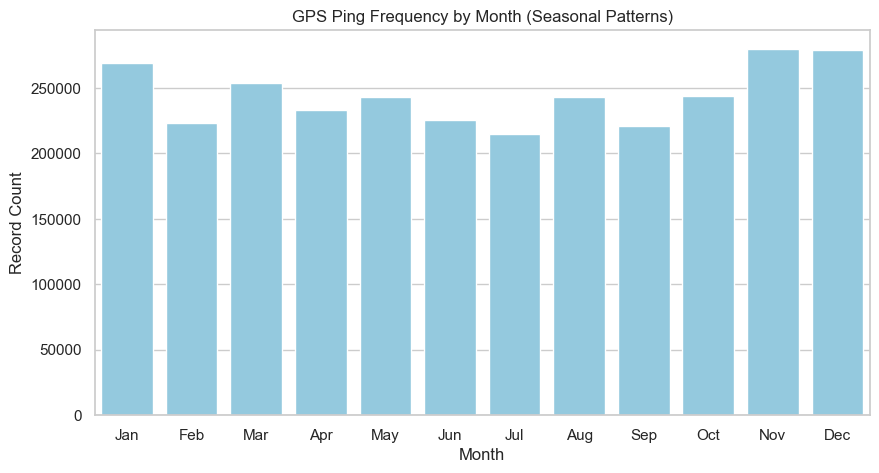

In [15]:
# Plot Monthly Distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=month_counts.index, y=month_counts.values, color='skyblue')
plt.title('GPS Ping Frequency by Month (Seasonal Patterns)')
plt.xlabel('Month')
plt.ylabel('Record Count')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

In [16]:
def haversine_vectorized(lon1, lat1, lon2, lat2):
    """
    Vectorized Haversine distance calculation for large pandas arrays.
    Returns distance in kilometers.
    """
    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c  # Radius of Earth in kilometers
    return km

# Sort values to ensure timeline chronological progression per elephant
df = df.sort_values(by=['individual-local-identifier', 'timestamp']).reset_index(drop=True)

# Generate shifted coordinate columns relative to each unique elephant tracking path
df['prev_lat'] = df.groupby('individual-local-identifier')['location-lat'].shift(1)
df['prev_long'] = df.groupby('individual-local-identifier')['location-long'].shift(1)

# Execute vectorized calculation 
df['distance_km'] = haversine_vectorized(
    df['location-long'], df['location-lat'], 
    df['prev_long'], df['prev_lat']
)

# Fill first row of each animal tracking sequence (NaN) with 0
df['distance_km'] = df['distance_km'].fillna(0)

# Output summary metric of total distances traveled
distance_summary = df.groupby('individual-local-identifier')['distance_km'].sum().sort_values(ascending=False)
print("Total Distance Covered (km) Per Elephant:")
print(distance_summary)

Total Distance Covered (km) Per Elephant:
individual-local-identifier
LA14    25813.445122
LA11    24506.772236
LA26    21064.364347
LA12    13961.044006
LA8     13498.970209
LA7     11000.770008
LA2      8944.519377
LA3      8804.684482
LA6      8763.929123
LA13     7511.308724
LA1      6661.021494
LA5      5408.982213
LA27     4677.521064
LA4      3374.547428
LA15      815.205352
Name: distance_km, dtype: float64


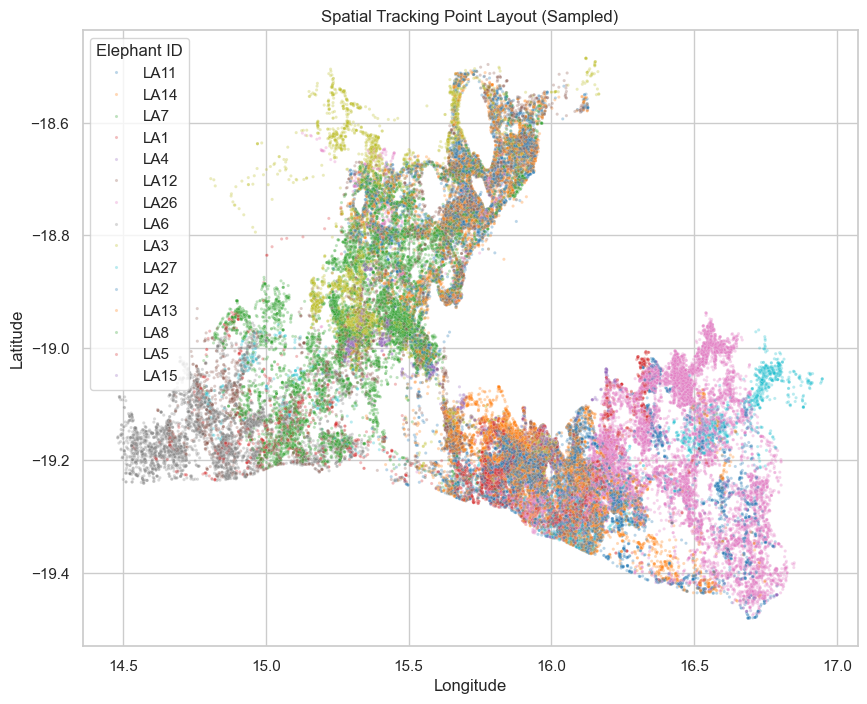

Interactive Heatmap exported as 'elephant_movement_heatmap.html'!


In [20]:
# Scatter Plot projection of geographic telemetry data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df.sample(100000, random_state=42), # Sampling prevents plot overflow while maintaining density
    x='location-long', y='location-lat', 
    hue='individual-local-identifier', 
    alpha=0.3, palette='tab10', s=5
)
plt.title('Spatial Tracking Point Layout (Sampled)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Elephant ID')
plt.show()

# Generate Interactive Folium Heatmap Sample
map_center = [df['location-lat'].mean(), df['location-long'].mean()]
base_map = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')

# Sample points for mapping fluidity
heat_data = df.sample(50000, random_state=42)[['location-lat', 'location-long']].values.tolist()
HeatMap(heat_data, radius=10, max_zoom=13).add_to(base_map)

# Save or display the map object
base_map.save("elephant_movement_heatmap.html")
print("Interactive Heatmap exported as 'elephant_movement_heatmap.html'!")

Analyzing home range spatial boundary for Top Elephant: LA26


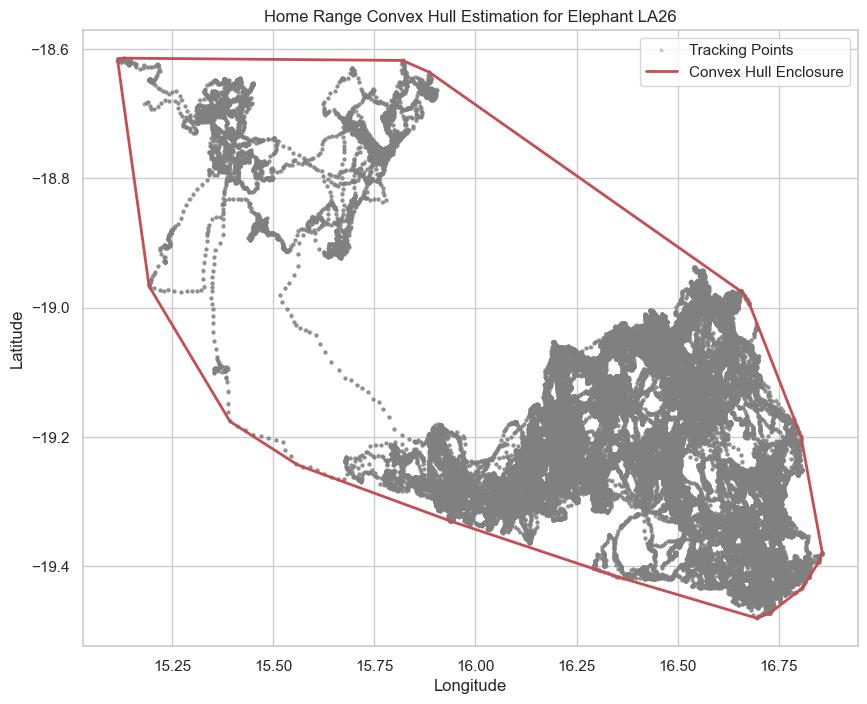

Area volume enclosed within this hull segment: 0.938976 units


In [21]:
# Dynamically select the elephant with the highest telemetry records
top_elephant = elephant_counts.index[0]
print(f"Analyzing home range spatial boundary for Top Elephant: {top_elephant}")

# Isolate coordinate slice
elephant_df = df[df['individual-local-identifier'] == top_elephant]
points = elephant_df[['location-long', 'location-lat']].values

# Compute Convex Hull Polygon
hull = ConvexHull(points)

# Plot Spatial Scatter with Overlay Enclosure Boundary
plt.figure(figsize=(10, 8))
plt.plot(points[:,0], points[:,1], 'o', markersize=2, color='gray', alpha=0.3, label='Tracking Points')

# Draw polygon perimeter connection loop
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'r-', linewidth=2)
plt.plot(points[hull.vertices[0], 0], points[hull.vertices[0], 1], 'r-', linewidth=2, label='Convex Hull Enclosure')

plt.title(f"Home Range Convex Hull Estimation for Elephant {top_elephant}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

print(f"Area volume enclosed within this hull segment: {hull.volume:.6f} units")

In [22]:
from sklearn.cluster import DBSCAN

# 1. Filter data for our primary elephant study subject
top_elephant = elephant_counts.index[0]
elephant_df = df[df['individual-local-identifier'] == top_elephant].copy()

# 2. Extract Lat/Long and convert to Radians for the Haversine metric
coords = elephant_df[['location-lat', 'location-long']].values
coords_radians = np.radians(coords)

# 3. Define DBSCAN Parameters
# We set 'eps' to 1.5 km (converted to radians) and 'min_samples' to 50 points
# This means an area must have at least 50 tracking points within a 1.5km radius to be a "core site"
kms_per_radian = 6371.0
epsilon_km = 1.5  
epsilon_radians = epsilon_km / kms_per_radian

# 4. Initialize and fit DBSCAN
db = DBSCAN(eps=epsilon_radians, min_samples=50, metric='haversine', algorithm='ball_tree')
elephant_df['cluster_label'] = db.fit_predict(coords_radians)

# Calculate statistics
num_clusters = len(set(elephant_df['cluster_label'])) - (1 if -1 in elephant_df['cluster_label'] else 0)
noise_points = list(elephant_df['cluster_label']).count(-1)

print(f"Analysis Complete for Elephant {top_elephant}:")
print(f"--> Core High-Density Hotspots Identified: {num_clusters}")
print(f"--> Transiting / Noise Coordinates Identified: {noise_points} out of {len(elephant_df)} total records")

Analysis Complete for Elephant LA26:
--> Core High-Density Hotspots Identified: 16
--> Transiting / Noise Coordinates Identified: 1279 out of 452758 total records


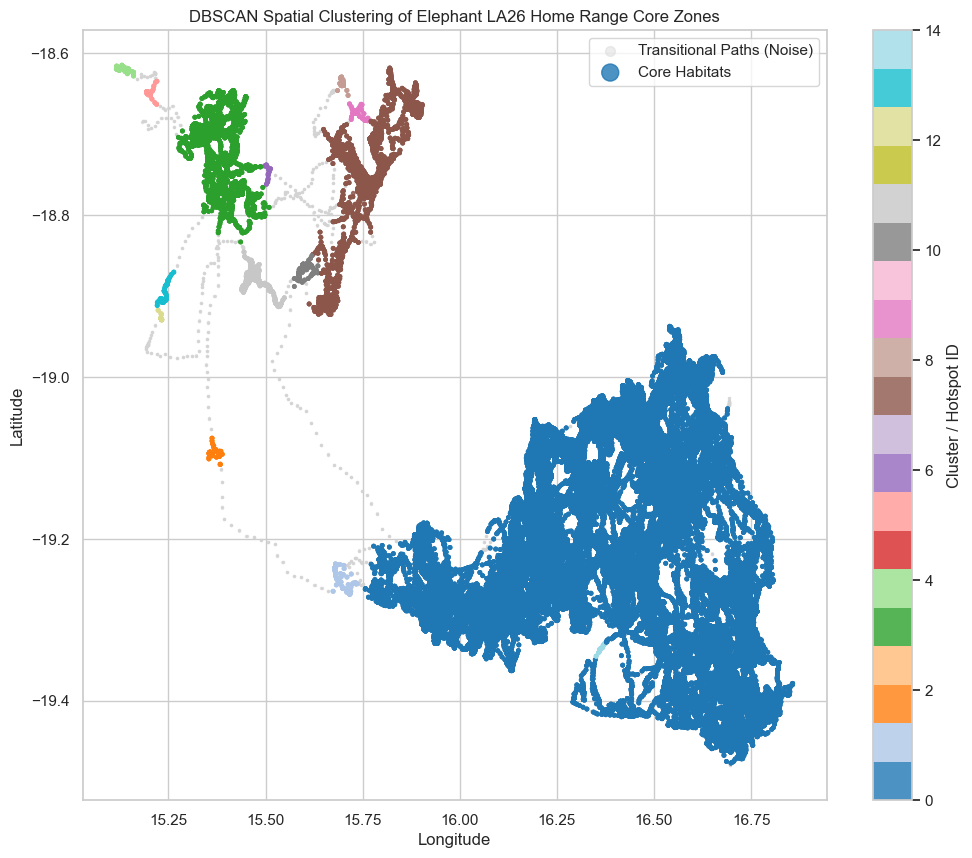

In [23]:
plt.figure(figsize=(12, 10))

# Plot noise points (unclustered transitional movements) in light gray
noise_mask = elephant_df['cluster_label'] == -1
plt.scatter(
    elephant_df.loc[noise_mask, 'location-long'], 
    elephant_df.loc[noise_mask, 'location-lat'], 
    c='lightgray', alpha=0.4, s=2, label='Transitional Paths (Noise)'
)

# Plot core clusters (hotspots) using a dynamic color palette
cluster_mask = elephant_df['cluster_label'] != -1
scatter = plt.scatter(
    elephant_df.loc[cluster_mask, 'location-long'], 
    elephant_df.loc[cluster_mask, 'location-lat'], 
    c=elephant_df.loc[cluster_mask, 'cluster_label'], 
    cmap='tab20', alpha=0.8, s=6, label='Core Habitats'
)

plt.colorbar(scatter, label='Cluster / Hotspot ID')
plt.title(f"DBSCAN Spatial Clustering of Elephant {top_elephant} Home Range Core Zones")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=5)
plt.show()

In [24]:
# Create base map around elephant coordinates midpoint
map_center = [elephant_df['location-lat'].mean(), elephant_df['location-long'].mean()]
cluster_map = folium.Map(location=map_center, zoom_start=10, tiles='OpenStreetMap')

# Filter down to just core cluster center medians to avoid overwhelming the map page
unique_clusters = set(elephant_df['cluster_label']) - {-1}

for cluster_id in unique_clusters:
    cluster_points = elephant_df[elephant_df['cluster_label'] == cluster_id]
    
    # Calculate geographical center of this specific habitat hotspot
    center_lat = cluster_points['location-lat'].mean()
    center_long = cluster_points['location-long'].mean()
    point_count = len(cluster_points)
    
    # Place an interactive marker with details
    folium.Marker(
        location=[center_lat, center_long],
        popup=f"Core Zone {cluster_id}<br>GPS Records: {point_count}<br>Est. Location: Central Habitats",
        icon=folium.Icon(color="green", icon="info-sign")
    ).add_to(cluster_map)

# Save map view
cluster_map.save("elephant_dbscan_hotspots.html")

Interactive DBSCAN core map successfully generated as 'elephant_dbscan_hotspots.html'!
